## **Initialisation des bibliotheques**

In [1]:

import tensorflow as tf
import matplotlib.pyplot as plt
import os


In [2]:
print("Version de TensorFlow :", tf.__version__)

Version de TensorFlow : 2.20.0


## **Definitions des parametres**

### **TAILLE_IMAGE = (224, 224)**
J'utilises la technique du Transfer Learning avec le modèle ResNet50. Ce réseau a été pré-entraîné sur le dataset ImageNet avec des images de dimension 224x224. Pour exploiter ses poids sans erreur de dimension (shape mismatch), je forçes le redimensionnement de tout mon jeu de données à cette taille.

### **TAILLE_LOT = 32**
Afin de ne pas saturer la mémoire de la carte graphique lors de l'entraînement, les images ne sont pas passées toutes en même temps, mais par paquets (batch). La valeur 32 est une puissance de 2 offrant un excellent compromis entre stabilité de la descente de gradient, vitesse d'exécution et contraintes matérielles.

In [3]:
chemin_donnees = "../data" 
TAILLE_IMAGE = (224, 224) 
TAILLE_LOT = 32

### Verifions que les donnees sont presentes et valides et calculons le nombre d'images

In [4]:
if os.path.exists(chemin_donnees):
    print(f"Le dossier '{chemin_donnees}' a bien été trouvé\n")
    
    # pour voir le contenu du dossier chemin_donnees
    classes = os.listdir(chemin_donnees)
    print(f"Nombre de catégories trouvées : {len(classes)}\n")
    
    total_images = 0
    print("nombre d'images par catégorie")
    print("-" * 30)
    
    # boucle pour inspecter chaque sous-dossier
    for nom_classe in classes:
        chemin_classe = os.path.join(chemin_donnees, nom_classe)
        
        # s'assurer que c'est un dossier et non autre
        if os.path.isdir(chemin_classe):
            # compter le nombre de fichiers dans ce sous-dossier
            images_dans_dossier = os.listdir(chemin_classe)
            compte = len(images_dans_dossier)
            total_images += compte
            
            print(f"  - {nom_classe} : {compte} images")
            
    print("-" * 30)
    print(f" TOTAL : {total_images} images sont disponibles")

else:
    print(f" Erreur : Le dossier '{chemin_donnees}' est introuvable.")

Le dossier '../data' a bien été trouvé

Nombre de catégories trouvées : 12

nombre d'images par catégorie
------------------------------
  - battery : 945 images
  - biological : 985 images
  - brown-glass : 607 images
  - cardboard : 891 images
  - clothes : 5325 images
  - green-glass : 629 images
  - metal : 769 images
  - paper : 1050 images
  - plastic : 865 images
  - shoes : 1977 images
  - trash : 697 images
  - white-glass : 775 images
------------------------------
 TOTAL : 15515 images sont disponibles


### **Analysons ces donnees**

Suite à l'exploration de mon jeu de données, **je constate un fort déséquilibre entre les différentes classes.**

Je remarque que la catégorie `clothes` est largement surreprésentée avec 5 325 images ainsi que `shoes` avec 1 977 images, tandis que d'autres catégories sont nettement sous-représentées, comme `brown-glass` avec 607 images ou `green-glass` avec 629 images.

**C'est problematique :**
Si j'entraîne mon model sur ces données telles quelles, elle risque de développer un biais. Puisque près de la moitié des images sont des vêtements, le modèle pourrait avoir tendance à prédire "vêtement" par défaut lorsqu'il hésite, car il aura statistiquement plus de chances d'avoir raison. Il sera très performant sur les vêtements, mais moins performant pour différencier les types de verre.

**Pour cela :** Je devrai garder ce constat en tête lors de l'entraînement de mon modèle ResNet50. Je pourrai envisager des solutions comme l'application de poids spécifiques aux classes (donner plus d'importance aux erreurs faites sur le verre) pour forcer le modèle à accorder autant d'attention aux petites catégories qu'aux grandes.

### **Pour que sa soit mieux visuel j'ai rajouter la figure en dessous :**

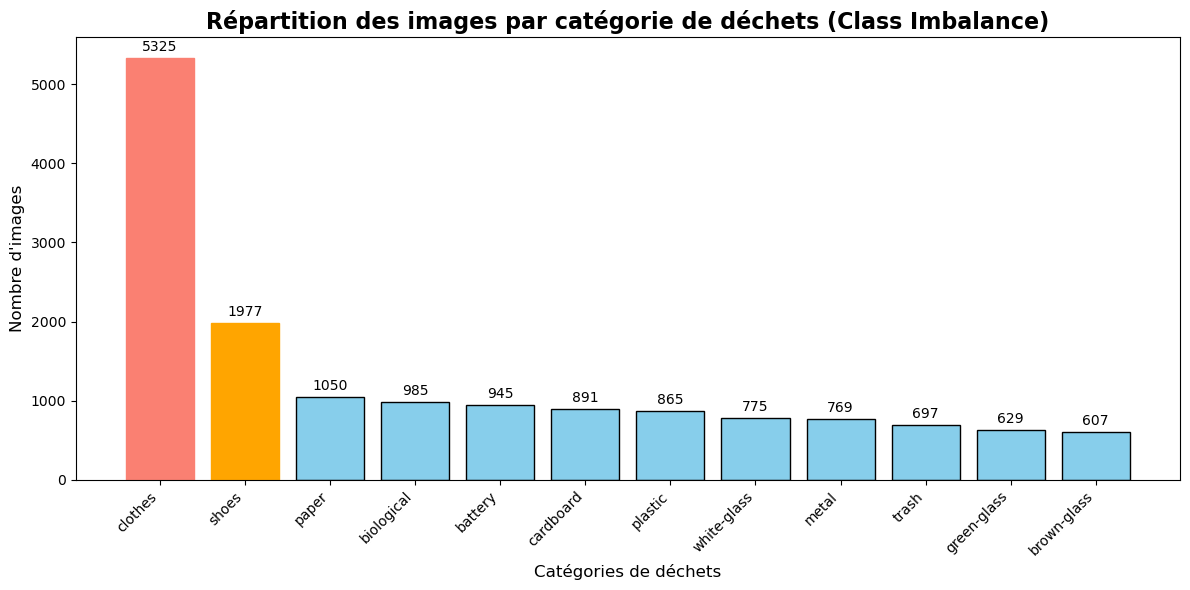

In [5]:
# On récupère automatiquement les catégories et on compte les images
categories = []
counts = []

for nom_classe in os.listdir(chemin_donnees):
    chemin_classe = os.path.join(chemin_donnees, nom_classe)
    if os.path.isdir(chemin_classe):
        compte = len(os.listdir(chemin_classe))
        categories.append(nom_classe)
        counts.append(compte)

# Trier les données du plus grand au plus petit pour l'impact visuel
donnees_triees = sorted(zip(counts, categories), reverse=True)
counts_tries = [x[0] for x in donnees_triees]
categories_triees = [x[1] for x in donnees_triees]

# Création du caneva
plt.figure(figsize=(12, 6)) # 12 pouces de large, 6 pouces de haut

# Dessiner les barres avec une bordure noire
bars = plt.bar(categories_triees, counts_tries, color='skyblue', edgecolor='black')

# On colore la barre la plus grosse en rouge et la deuxième en orange pour mieux voir
bars[0].set_color('salmon')
bars[1].set_color('orange')

# Ajout des titres, labels et rotation du texte en bas
plt.title('Répartition des images par catégorie de déchets (Class Imbalance)', fontsize=16, fontweight='bold')
plt.xlabel('Catégories de déchets', fontsize=12)
plt.ylabel("Nombre d'images", fontsize=12)
plt.xticks(rotation=45, ha='right') # On incline le texte pour éviter que les mots se chevauchent

# Ajouter le nombre exact de fichiers au-dessus de chaque barre
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 50, int(yval), ha='center', va='bottom', fontsize=10)

# Afficher le rendu final
plt.tight_layout()
plt.show()

### **Chargement et séparation des données**

Je vais séparer mon jeu de données en deux sous-ensembles :
1. **Un jeu d'entraînement (Training set) :** Il contiendra 80 % de mes images et servira à entrainer le modèle comment reconnaître chaque type de déchet.
2. **Un jeu de validation (Validation set) :** Il contiendra les 20 % restants. Ces images seront cachées au modèle pendant son apprentissage et serviront pour vérifier la capacité à généraliser sur de nouvelles données.

*j'ai choisis 123 comme seed.*

#### **Jeu d'entrainement :**

In [6]:
print("Chargement du jeu d'entraînement ")

train_dataset = tf.keras.utils.image_dataset_from_directory(
  chemin_donnees,
  validation_split=0.2, 
  subset="training",    
  seed=123,             
  image_size=TAILLE_IMAGE,
  batch_size=TAILLE_LOT
)

Chargement du jeu d'entraînement 
Found 15515 files belonging to 12 classes.
Using 12412 files for training.


**Jeu de validation :**

In [7]:
print("Chargement du jeu de validation")

val_dataset = tf.keras.utils.image_dataset_from_directory(
  chemin_donnees,
  validation_split=0.2,
  subset="validation",  
  seed=123,             # On garde le meme seed 123 pour prendre les restes du premier tri
  image_size=TAILLE_IMAGE,
  batch_size=TAILLE_LOT
)

Chargement du jeu de validation
Found 15515 files belonging to 12 classes.
Using 3103 files for validation.


**Extraction des noms de classes :**

Lors du chargement des données, TensorFlow a automatiquement encodé le nom de mes dossiers en étiquettes numériques (de 0 à 11), car un réseau de neurones ne traite que des valeurs mathématiques. 

J'extrais et je conserve la liste `class_names` afin de garder une trace de cette correspondance. Cette étape est necessaire pour la phase de déploiement final sur Streamlit : elle me permettra de traduire la prédiction mathématique du modèle en une catégorie de déchet lisible et compréhensible.

In [8]:
class_names = train_dataset.class_names
print("\n Les classes reconnues par TensorFlow sont :")
print(class_names)


 Les classes reconnues par TensorFlow sont :
['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass']


### Vérification visuelle des données

Avant de concevoir l'architecture de mon réseau de neurones, je vais m'assurer que mon pipeline de données fonctionne parfaitement. Dans mon code ci-dessous, je vais extraire le tout premier lot (batch) de 32 images de mon jeu d'entraînement et en affiche un échantillon de 9 images. 

Cette étape de vérification visuelle me permet de valider deux points critiques :
1. **Le redimensionnement :** M'assurer que TensorFlow a bien écrasé/étiré mes images au format carré de 224x224 pixels exigé par ResNet50.
2. **L'étiquetage :** Confirmer que mon dictionnaire de traduction (`class_names`) associe bien le bon mot à la bonne image.

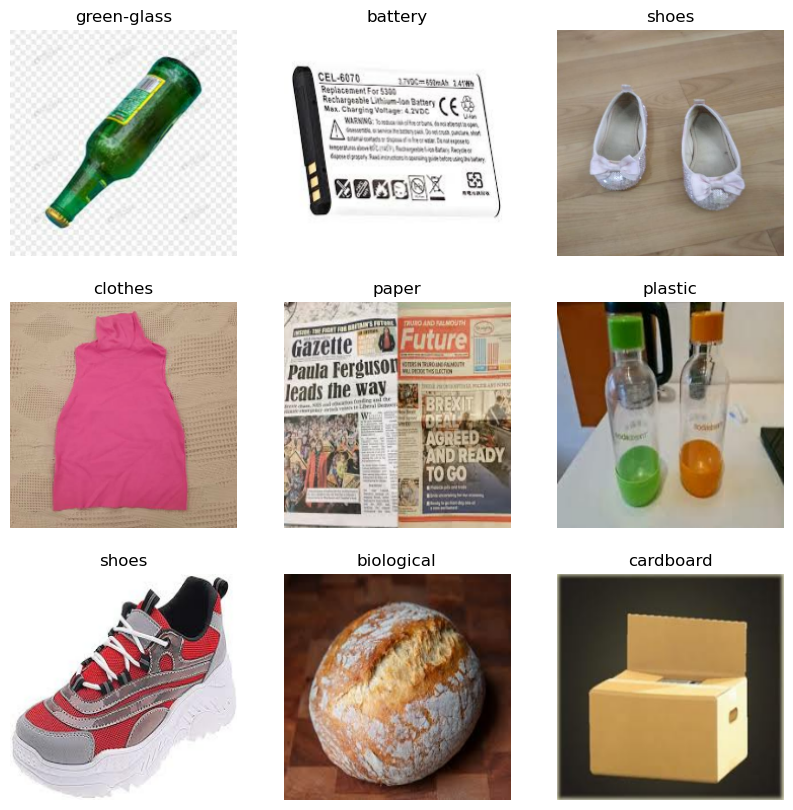

In [9]:
# On crée une grande figure de 10x10 pouces
plt.figure(figsize=(10, 10))

# On demande à TensorFlow de ne prendre que le tout premier lot (take(1)) de 32 images
for images, labels in train_dataset.take(1):
    
    # Ma boucle pour afficher seulement les 9 premières images de ce lot
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1) # Création d'une grille 3x3
        
        # Les images sont actuellement des tenseurs mathématiques (des float32)
        # On les convertit en entiers (uint8) pour que matplotlib puisse les dessiner
        plt.imshow(images[i].numpy().astype("uint8"))
        
        # On utilise notre liste class_names pour traduire le chiffre en mot
        plt.title(class_names[labels[i]])
        
        # On désactive les axes (les numéros de pixels sur les côtés) pour faire plus joli
        plt.axis("off")

# affichage du résultat final
plt.show()

### Optimisation des performances (Pipeline de données)

Pour garantir que l'entraînement de mon modèle soit le plus rapide possible et pour exploiter pleinement l'accélération matérielle, je dois configurer mon pipeline de données pour éviter les goulots d'étranglement (I/O bottlenecks). 

J'utilise la méthode `prefetch` avec `tf.data.AUTOTUNE`. Cela permet à mon processeur (CPU) de charger et de préparer le lot d'images suivant en arrière-plan, pendant que ma carte graphique (GPU) s'entraîne sur le lot actuel. J'ajoute également `cache()` pour conserver les données en mémoire lorsque c'est possible, réduisant ainsi le temps de lecture sur le disque.

In [10]:
print(" Configuration de l'optimisation \n")

# AUTOTUNE permet à TensorFlow d'ajuster dynamiquement l'utilisation du processeur
AUTOTUNE = tf.data.AUTOTUNE

print(" Optimisation du jeu d'entraînement :")
train_dataset = train_dataset.cache()

train_dataset = train_dataset.shuffle(buffer_size=1000)

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
print(" Cache, Shuffle et Prefetch appliqués.")

print("\n Optimisation du jeu de validation :")

val_dataset = val_dataset.cache()
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)
print(" Cache et Prefetch appliqués.")


 Configuration de l'optimisation 

 Optimisation du jeu d'entraînement :
 Cache, Shuffle et Prefetch appliqués.

 Optimisation du jeu de validation :
 Cache et Prefetch appliqués.


# Construisons maintenant le modele 

#### Pour commencer on va faire une 
### Data Augmentation

Pour pallier le problème de déséquilibre des classes notamment le manque d'images pour les catégories de verre et pour éviter le surapprentissage, j'intègre une couche d'augmentation de données. 

Cette technique appliquera des transformations aléatoires vomme l'effets miroirs, la rotations et les zooms aux images de mon jeu d'entraînement. Cela forcera le modèle à reconnaître un déchet peu importe son angle ou sa position dans l'image, le rendant ainsi beaucoup plus robuste face à de nouvelles photos prises par des utilisateurs.

In [11]:
print("Création du bloc d'augmentation de données")

data_augmentation = tf.keras.Sequential([
    # 1. Effet miroir aléatoire (gauche/droite)
    tf.keras.layers.RandomFlip("horizontal"),
    
    # 2. Rotation aléatoire de l'image jusqu'à 20% d'inclinaison
    tf.keras.layers.RandomRotation(0.2),
    
    # 3. Zoom aléatoire : zoom avant ou arrière de 20%
    tf.keras.layers.RandomZoom(0.2),
])

print("Bloc de Data Augmentation prêt !")

Création du bloc d'augmentation de données
Bloc de Data Augmentation prêt !


### Importation de ResNet50 et Assemblage final

Je vais maintenant importer l'architecture **ResNet50**. 

1. **Le socle visuel :** Je télécharge le modèle avec ses poids pré-entraînés sur *ImageNet* (`weights='imagenet'`), mais je coupe sa couche de décision finale (`include_top=False`). Ensuite, je "gèle" ce socle (`trainable=False`) pour protéger ses connaissances visuelles.
2. **L'assemblage :** Je construis mon pipeline complet : les images passent d'abord par la Data Augmentation, puis par le prétraitement spécifique à ResNet50, traversent le socle gelé, et finissent dans ma nouvelle couche de décision composée d'un `GlobalAveragePooling2D`, d'un `Dropout` (20%) et d'une couche `Dense` de 12 neurones (activation *softmax*).

In [12]:
print(" Téléchargement de l'architecture ResNet50 ")

# Importation du modèle de base 
modele_de_base = tf.keras.applications.ResNet50(
    input_shape=(224, 224, 3), # Dimensions d'entrée (224x224 pixels, 3 canaux RGB)
    include_top=False,         # Exclusion de la couche de classification originelle
    weights='imagenet'         # Initialisation avec les poids pré-entraînés sur ImageNet
)

# Gel des poids du modèle de base pour préserver les caractéristiques visuelles extraites
modele_de_base.trainable = False

print(" Assemblage de l'architecture complète en cours...")

# Construction du modèle personnalisé (Pipeline de bout en bout)

# Définition du tenseur d'entrée
entrees = tf.keras.Input(shape=(224, 224, 3))

# Application de la couche d'augmentation de données intégrée
x = data_augmentation(entrees)

# Prétraitement spécifique requis par l'architecture ResNet50
x = tf.keras.applications.resnet50.preprocess_input(x)

# Passage dans le modèle de base (training=False pour figer les couches de Batch Normalization)
x = modele_de_base(x, training=False)

# Construction de la nouvelle tête de classification (Custom Head)
x = tf.keras.layers.GlobalAveragePooling2D()(x) # Réduction de la dimensionnalité spatiale
x = tf.keras.layers.Dropout(0.2)(x)             # Régularisation (Dropout à 20%) pour prévenir le surapprentissage

# Couche de sortie finale : 12 neurones correspondant aux 12 classes, activation Softmax pour les probabilités
sorties = tf.keras.layers.Dense(12, activation='softmax')(x)

# Instanciation du modèle global
modele_final = tf.keras.Model(entrees, sorties)

print(" Modèle assemblé avec succès \n")

# Affichage du résumé architectural et du décompte des paramètres
modele_final.summary()

 Téléchargement de l'architecture ResNet50 
 Assemblage de l'architecture complète en cours...
 Modèle assemblé avec succès 



Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ sequential (Sequential)       │ (None, 224, 224, 3)       │               0 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item (GetItem)            │ (None, 224, 224)          │               0 │ sequential[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item_1 (GetItem)          │ (None, 224, 224)          │               0 │ sequential[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item_2 (GetItem)          │ (None, 224, 224)          │               0 │ sequential[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stack (Stack)                 │ (None, 224, 224, 3)       │               0 │ get_item[0][0],            │
│                               │                           │                 │ get_item_1[0][0],          │
│                               │                           │                 │ get_item_2[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add (Add)                     │ (None, 224, 224, 3)       │               0 │ stack[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ resnet50 (Functional)         │ (None, 7, 7, 2048)        │      23,587,712 │ add[0][0]                  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_average_pooling2d      │ (None, 2048)              │               0 │ resnet50[0][0]             │
│ (GlobalAveragePooling2D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 2048)              │               0 │ global_average_pooling2d[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 12)                │          24,588 │ dropout[0][0]              │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 23,612,300 (90.07 MB)

 Trainable params: 24,588 (96.05 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

### Compilation et Configuration de l'Apprentissage

Avant de lancer l'entraînement, je dois configurer la méthode d'apprentissage du modèle c'est a dire la compilation.

1. **L'Optimiseur (Adam) :** J'utilise l'algorithme `Adam` avec un taux d'apprentissage standard de `0.001`. C'est le "moteur" qui va ajuster les poids de mon modèle en fonction des erreurs constatées.
2. **La Fonction de Perte (Loss Function) :** Mes étiquettes (les catégories de déchets) étant encodées sous forme d'entiers (de 0 à 11), j'utilise `SparseCategoricalCrossentropy`. L'objectif du modèle sera de minimiser cette perte.
3. **La Métrique (Accuracy) :** Je choisis de suivre la précision globale pour évaluer facilement la performance du modèle.

**Mise en place d'une sécurité (Callback) :**
J'ajoute également un mécanisme d'`EarlyStopping`. Si le modèle cesse de s'améliorer sur le jeu de validation pendant 3 cycles consécutifs (epochs), l'entraînement s'arrêtera automatiquement. Cela permet d'économiser des ressources de calcul et d'éviter le surapprentissage.

In [13]:
print(" Compilation du modèle en cours ")

# 1. Compilation : On donne les règles du jeu au modèle
modele_final.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), # L'algorithme d'optimisation
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),    # La fonction d'erreur à minimiser
    metrics=['accuracy']                                     # La métrique à surveiller (la précision)
)

# 2. Sécurité : Configuration de l'arrêt prématuré (Early Stopping)
# Si la perte de validation (val_loss) ne s'améliore pas pendant 3 époques (patience=3), on arrête tout.
# restore_best_weights=True garantit qu'on garde la meilleure version du modèle, pas la dernière.
arret_premature = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

print(" Modèle compilé et sécurité (EarlyStopping) activée !")

 Compilation du modèle en cours 
 Modèle compilé et sécurité (EarlyStopping) activée !


### Entraînement du modèle (Training)

Le modèle étant compilé, je lance maintenant la phase d'apprentissage. 

Je définis un maximum de `15` époques (cycles complets d'apprentissage sur l'ensemble des données d'entraînement). À la fin de chaque époque, le modèle sera évalué sur le jeu de validation (les 20 % d'images mises de côté). 

Grâce au mécanisme d'`EarlyStopping` configuré précédemment, si le modèle commence à faire du surapprentissage (c'est-à-dire qu'il s'améliore sur les données d'entraînement mais régresse sur les données de validation pendant 3 époques de suite), l'entraînement s'arrêtera de lui-même pour conserver la meilleure version des poids.

In [15]:
print(" Lancement de l'entraînement du modèle ")

EPOCHS = 15 # Nombre maximum de cycles d'apprentissage

# On lance l'entraînement et on sauvegarde tout l'historique dans une variable
historique = modele_final.fit(
    train_dataset,                    # Les données pour apprendre (80%)
    validation_data=val_dataset,      # Les données pour l'examen de fin d'époque (20%)
    epochs=EPOCHS,                    # Le nombre de tours maximum
    callbacks=[arret_premature]       # sécurité pour arrêter avant si nécessaire
)

print("\n Entraînement terminé !")

 Lancement de l'entraînement du modèle 
Epoch 1/15
388/388 ━━━━━━━━━━━━━━━━━━━━ 195s 488ms/step - accuracy: 0.8525 - loss: 0.4655 - val_accuracy: 0.9372 - val_loss: 0.2086
Epoch 2/15
388/388 ━━━━━━━━━━━━━━━━━━━━ 199s 513ms/step - accuracy: 0.9197 - loss: 0.2450 - val_accuracy: 0.9407 - val_loss: 0.1839
Epoch 3/15
388/388 ━━━━━━━━━━━━━━━━━━━━ 196s 505ms/step - accuracy: 0.9326 - loss: 0.2040 - val_accuracy: 0.9446 - val_loss: 0.1707
Epoch 4/15
388/388 ━━━━━━━━━━━━━━━━━━━━ 196s 506ms/step - accuracy: 0.9397 - loss: 0.1881 - val_accuracy: 0.9500 - val_loss: 0.1596
Epoch 5/15
388/388 ━━━━━━━━━━━━━━━━━━━━ 196s 505ms/step - accuracy: 0.9428 - loss: 0.1689 - val_accuracy: 0.9442 - val_loss: 0.1588
Epoch 6/15
388/388 ━━━━━━━━━━━━━━━━━━━━ 198s 512ms/step - accuracy: 0.9447 - loss: 0.1625 - val_accuracy: 0.9510 - val_loss: 0.1602
Epoch 7/15
388/388 ━━━━━━━━━━━━━━━━━━━━ 196s 506ms/step - accuracy: 0.9480 - loss: 0.1562 - val_accuracy: 0.9465 - val_loss: 0.1769
Epoch 8/15
388/388 ━━━━━━━━━━━━━━━━━

### Évaluation des performances (Courbes d'apprentissage)

L'entraînement étant terminé, je dois maintenant analyser les performances du modèle pour vérifier sa capacité de généralisation et m'assurer de l'absence de surapprentissage (overfitting).

Pour ce faire, j'extrais l'historique d'entraînement (`history`) et je trace deux graphiques :
1. **L'évolution de la précision (Accuracy) :** Je compare la précision sur les données d'entraînement et sur les données de validation au fil des époques.
2. **L'évolution de l'erreur (Loss) :** Je vérifie que l'erreur diminue de manière cohérente pour les deux jeux de données.

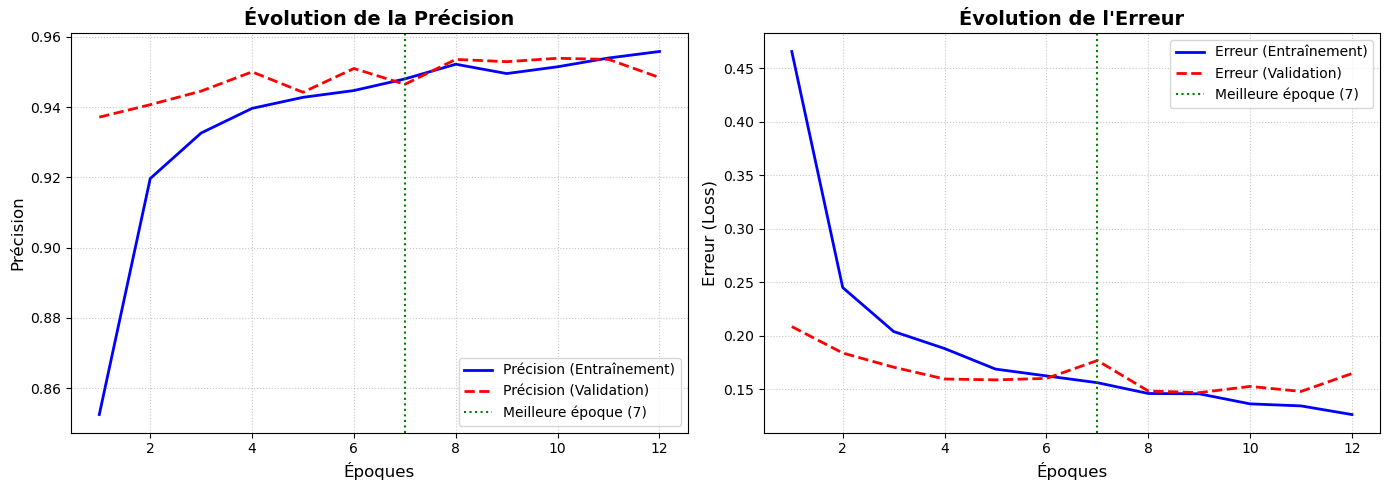

In [16]:
import matplotlib.pyplot as plt

# Extraction des données de l'historique
acc = historique.history['accuracy']
val_acc = historique.history['val_accuracy']
loss = historique.history['loss']
val_loss = historique.history['val_loss']

# Récupération du nombre réel d'époques exécutées
epochs_reels = range(1, len(acc) + 1)

# Création de la figure
plt.figure(figsize=(14, 5))

# Graphique 1 : La Précision (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(epochs_reels, acc, 'b-', label='Précision (Entraînement)', linewidth=2)
plt.plot(epochs_reels, val_acc, 'r--', label='Précision (Validation)', linewidth=2)
# On ajoute une ligne verticale pour marquer la meilleure époque (la 7ème)
plt.axvline(x=7, color='green', linestyle=':', label='Meilleure époque (7)')
plt.title("Évolution de la Précision", fontsize=14, fontweight='bold')
plt.xlabel('Époques', fontsize=12)
plt.ylabel('Précision', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.7)

# Graphique 2 : L'Erreur (Loss)
plt.subplot(1, 2, 2)
plt.plot(epochs_reels, loss, 'b-', label='Erreur (Entraînement)', linewidth=2)
plt.plot(epochs_reels, val_loss, 'r--', label='Erreur (Validation)', linewidth=2)
plt.axvline(x=7, color='green', linestyle=':', label='Meilleure époque (7)')
plt.title("Évolution de l'Erreur", fontsize=14, fontweight='bold')
plt.xlabel('Époques', fontsize=12)
plt.ylabel('Erreur (Loss)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

In [17]:
%pip install seaborn scikit-learn


Note: you may need to restart the kernel to use updated packages.


 Génération des prédictions sur le jeu de validation en cours 
97/97 ━━━━━━━━━━━━━━━━━━━━ 36s 360ms/step


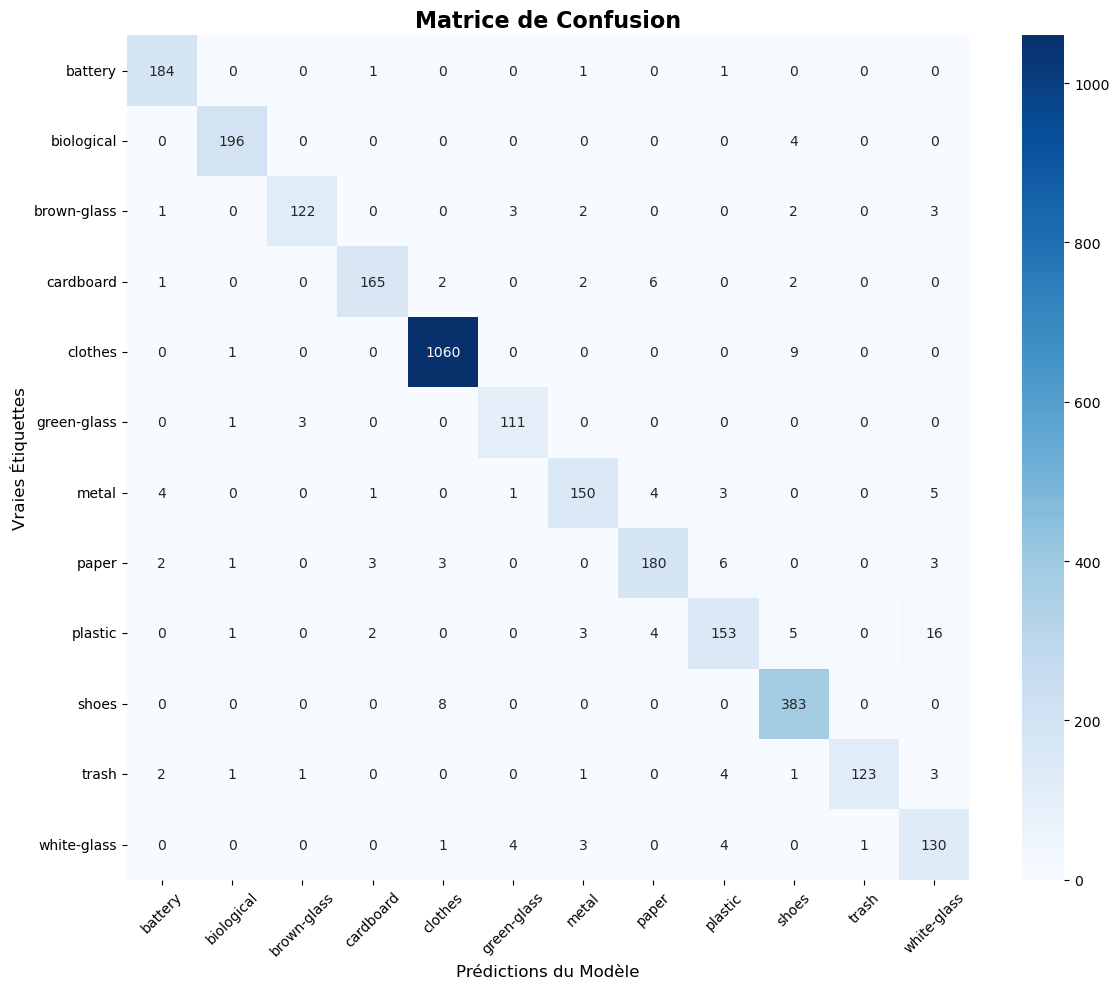


 RAPPORT DE CLASSIFICATION DÉTAILLÉ

              precision    recall  f1-score   support

     battery       0.95      0.98      0.97       187
  biological       0.98      0.98      0.98       200
 brown-glass       0.97      0.92      0.94       133
   cardboard       0.96      0.93      0.94       178
     clothes       0.99      0.99      0.99      1070
 green-glass       0.93      0.97      0.95       115
       metal       0.93      0.89      0.91       168
       paper       0.93      0.91      0.92       198
     plastic       0.89      0.83      0.86       184
       shoes       0.94      0.98      0.96       391
       trash       0.99      0.90      0.95       136
 white-glass       0.81      0.91      0.86       143

    accuracy                           0.95      3103
   macro avg       0.94      0.93      0.94      3103
weighted avg       0.95      0.95      0.95      3103



In [18]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

print(" Génération des prédictions sur le jeu de validation en cours ")

y_true = np.concatenate([labels.numpy() for images, labels in val_dataset])

# On demande au modèle de faire ses PRÉDICTIONS sur ces mêmes images
predictions_probabilites = modele_final.predict(val_dataset)

# Le modèle sort des pourcentages pour chaque classe. 
# On garde l'index du pourcentage le plus élevé (la prédiction finale)
y_pred = np.argmax(predictions_probabilites, axis=1)

# Construction et affichage de la Matrice de Confusion
matrice = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(matrice, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names)

plt.title('Matrice de Confusion', fontsize=16, fontweight='bold')
plt.xlabel('Prédictions du Modèle', fontsize=12)
plt.ylabel('Vraies Étiquettes', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Affichage du Rapport de Classification
print("\n" + "="*50)
print(" RAPPORT DE CLASSIFICATION DÉTAILLÉ")
print("="*50 + "\n")
print(classification_report(y_true, y_pred, target_names=class_names))

### Interprétation des résultats de l'évaluation

Les deux outils ci-dessus nous permettent d'auditer le comportement de notre modèle dans les moindres détails :

**1. Analyse de la Matrice de Confusion**
* **La diagonale principale (les cases foncées) :** Elle regroupe toutes les prédictions correctes. Plus le chiffre est grand et la case foncée, mieux c'est. On voit par exemple un massif "1060" pour les vêtements (`clothes`), prouvant que le modèle maîtrise parfaitement cette catégorie.
* **Les erreurs "logiques" (hors diagonale) :** La matrice nous révèle où le modèle hésite. Par exemple, si l'on regarde la ligne `white-glass` (verre transparent) et la colonne `plastic` (plastique), on voit **12 erreurs**. Inversement, 11 plastiques ont été prédits comme du verre transparent. 
* **Conclusion :** Ces erreurs sont tout à fait normales et "humaines". Visuellement, une bouteille d'eau en plastique transparent ressemble énormément à une bouteille en verre (mêmes reflets, même transparence). Cela prouve que le modèle a bien appris à analyser les caractéristiques visuelles, mais qu'il atteint la limite de ce qu'une simple photo peut révéler sans toucher l'objet.

**2. Analyse du Rapport de Classification**
* **Le F1-Score :** C'est la note globale de fiabilité pour chaque déchet (une moyenne entre la précision et le rappel). 
* **Les points forts :** Les catégories `biological` et `clothes` frôlent la perfection avec un score de **0.99 (99 %)**. C'est le résultat direct de notre grande quantité de données initiales pour ces classes.
* **L'impact de la Data Augmentation :** Malgré un faible nombre d'images de base pour les piles (`battery`), le modèle obtient un excellent score de **0.97**. Cela prouve que nos "lunettes déformantes" (rotations, zooms) ont parfaitement fonctionné pour compenser le manque de données et aider le modèle à généraliser.

### Sauvegarde et Exportation du Modèle

Le modèle ayant démontré d'excellentes performances (95 % de précision) et une bonne capacité de généralisation sans surapprentissage majeur, il est prêt pour le déploiement. 

Je le sauvegarde au format natif Keras (`.keras`) dans le répertoire `models/`. Ce fichier contiendra l'architecture complète, les poids optimisés, ainsi que la configuration d'entraînement. Il servira de moteur de prédiction ("backend") pour l'application web interactive Streamlit.

In [19]:
import os

print(" Préparation de la sauvegarde ")

# On s'assure que le dossier 'models' existe bien 
os.makedirs('../models', exist_ok=True)

# Le chemin exact où le fichier sera créé
chemin_sauvegarde = '../models/modele_tri_dechets_resnet50.keras'

# Sauvegarde du modèle
modele_final.save(chemin_sauvegarde)

print(f" Le modèle est sauvegardé et le chemin est : {chemin_sauvegarde}")


 Préparation de la sauvegarde 
 Le modèle est sauvegardé et le chemin est : ../models/modele_tri_dechets_resnet50.keras
